# Stage 2: Returns and Risk

This notebook transforms Stage 1 price data into portfolio-ready return and volatility outputs. It now includes a modular data-quality layer that repairs price anomalies, stabilizes returns, and keeps the runtime Yahoo Finance access pattern unchanged.


## Why Returns and Volatility Matter

- Portfolio optimization does not use raw prices directly because assets trade at different absolute price levels.
- Returns convert price changes into a comparable scale across assets.
- Simple returns are intuitive percentage changes.
- Log returns are additive through time and remain the core return representation for downstream risk analysis.
- A data-quality layer is now applied before analytics so extreme Yahoo Finance anomalies do not distort volatility, covariance, or clustering.
- Volatility measures how much returns vary over time and serves as a first-pass risk proxy before covariance and correlation are studied in later stages.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_pipeline import SAMPLE_UNIVERSE, DataPreprocessor, YahooFinanceProvider


In [2]:
symbols = list(SAMPLE_UNIVERSE)
start_date = "2019-01-01"
end_date = "2020-01-31"

provider = YahooFinanceProvider()
market_data = provider.get_market_data(symbols, start_date, end_date)

prices_df, _data_quality_summary = DataPreprocessor.handle_missing_values(market_data.prices_df)
volume_df = market_data.volume_df.copy()

stage_2_outputs = DataPreprocessor.build_returns_risk_outputs(prices_df)

quality_report_df = stage_2_outputs.quality_report_df
anomaly_report_df = stage_2_outputs.anomaly_report_df
repair_report_df = stage_2_outputs.repair_report_df
outlier_report_df = stage_2_outputs.outlier_report_df
stabilization_report_df = stage_2_outputs.stabilization_report_df
simple_returns_df = stage_2_outputs.simple_returns_df
returns_df = stage_2_outputs.returns_df
log_returns_df = stage_2_outputs.log_returns_df
volatility_summary_df = stage_2_outputs.volatility_summary_df
rolling_volatility_df = stage_2_outputs.rolling_volatility_df
return_comparison_df = stage_2_outputs.return_comparison_df

print(f"prices_df shape: {prices_df.shape}")
print(f"volume_df shape: {volume_df.shape}")
print(f"quality_report_df shape: {quality_report_df.shape}")
print(f"anomaly_report_df shape: {anomaly_report_df.shape}")
print(f"repair_report_df shape: {repair_report_df.shape}")
print(f"outlier_report_df shape: {outlier_report_df.shape}")
print(f"stabilization_report_df shape: {stabilization_report_df.shape}")
print(f"simple_returns_df shape: {simple_returns_df.shape}")
print(f"log_returns_df shape: {log_returns_df.shape}")
print(f"rolling_volatility_df shape: {rolling_volatility_df.shape}")


prices_df shape: (265, 28)
volume_df shape: (265, 28)
simple_returns_df shape: (264, 28)
log_returns_df shape: (264, 28)
rolling_volatility_df shape: (264, 56)


In [3]:
prices_df.head()

Ticker,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,1295.010864,623.916870,280.425446,495.704285,498.221893,28.177999,375.389374,504.392517,1607.500488,350.957031,...,94.748306,75.199844,498.490601,271.551178,402.755890,205.281998,1561.000488,556.562683,3878.702881,112.147346
2019-01-02,1306.105103,616.705933,274.413208,487.648682,497.075256,28.288500,370.109589,499.790253,1592.774048,351.777161,...,93.823143,73.413834,491.998260,266.384766,408.794189,201.065826,1577.817871,551.106079,3875.703857,111.769699
2019-01-03,1310.826172,604.671204,275.159241,485.611145,492.545990,28.470501,370.891815,495.868958,1596.165771,350.474609,...,90.856270,72.586662,485.928284,263.846954,405.124756,196.802780,1558.662109,535.007568,3773.105957,111.752525
2019-01-04,1308.512817,616.258301,283.014648,485.990204,496.874573,28.298000,364.634369,497.195618,1590.185913,352.356049,...,92.961800,73.658249,488.551880,269.783722,402.988159,200.316254,1539.711670,527.151672,3787.133789,111.392021
2019-01-07,1318.096558,634.012085,285.208893,487.174866,488.972351,28.224501,368.232361,497.946930,1593.086670,354.768127,...,94.333580,74.617043,491.264496,268.560120,400.201233,201.393738,1556.980469,532.105103,3798.936523,111.323364


In [4]:
display(simple_returns_df.head())
display(log_returns_df.head())
display(return_comparison_df)
display(volatility_summary_df)

Ticker,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,0.008567,-0.011558,-0.021440,-0.016251,-0.002301,0.003922,-0.014065,-0.009124,-0.009161,0.002337,...,-0.009764,-0.023750,-0.013024,-0.019026,0.014992,-0.020538,0.010773,-0.009804,-0.000773,-0.003367
2019-01-03,0.003615,-0.019515,0.002719,-0.004178,-0.009112,0.006434,0.002113,-0.007846,0.002129,-0.003703,...,-0.031622,-0.011267,-0.012337,-0.009527,-0.008976,-0.021202,-0.012141,-0.029211,-0.026472,-0.000154
2019-01-04,-0.001765,0.019163,0.028549,0.000781,0.008788,-0.006059,-0.016871,0.002675,-0.003746,0.005368,...,0.023174,0.014763,0.005399,0.022501,-0.005274,0.017853,-0.012158,-0.014684,0.003718,-0.003226
2019-01-07,0.007324,0.028809,0.007753,0.002438,-0.015904,-0.002597,0.009867,0.001511,0.001824,0.006846,...,0.014756,0.013017,0.005552,-0.004535,-0.006916,0.005379,0.011216,0.009397,0.003117,-0.000616
2019-01-08,0.003761,0.021100,0.013233,-0.000778,0.004631,-0.002144,0.003824,-0.008323,-0.007900,0.033859,...,-0.002705,-0.005543,-0.000091,0.030374,0.040042,0.000930,-0.002292,0.003418,-0.002661,0.004009


asset,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,0.008530,-0.011625,-0.021673,-0.016384,-0.002304,0.003914,-0.014165,-0.009166,-0.009203,0.002334,...,-0.009812,-0.024037,-0.013110,-0.019209,0.014881,-0.020752,0.010716,-0.009852,-0.000774,-0.003373
2019-01-03,0.003608,-0.019707,0.002715,-0.004187,-0.009154,0.006413,0.002111,-0.007877,0.002127,-0.003710,...,-0.032133,-0.011331,-0.012414,-0.009573,-0.009017,-0.021430,-0.012215,-0.029646,-0.026829,-0.000154
2019-01-04,-0.001766,0.018981,0.028149,0.000780,0.008750,-0.006077,-0.017015,0.002672,-0.003753,0.005354,...,0.022910,0.014655,0.005385,0.022251,-0.005288,0.017695,-0.012233,-0.014793,0.003711,-0.003231
2019-01-07,0.007297,0.028402,0.007723,0.002435,-0.016032,-0.002601,0.009819,0.001510,0.001823,0.006822,...,0.014649,0.012933,0.005537,-0.004546,-0.006940,0.005365,0.011153,0.009353,0.003112,-0.000617
2019-01-08,0.003754,0.020880,0.013146,-0.000778,0.004620,-0.002146,0.003816,-0.008358,-0.007931,0.033298,...,-0.002709,-0.005558,-0.000091,0.029922,0.039261,0.000930,-0.002294,0.003412,-0.002665,0.004001


,mean_simple_return,mean_log_return,mean_abs_difference,max_abs_difference,return_correlation
asset,,,,,
ASIANPAINT.NS,0.001165,0.001068,0.000097,0.002954,0.999854
AXISBANK.NS,0.000718,0.000584,0.000134,0.002109,0.999894
BHARTIARTL.NS,0.002186,0.001942,0.000244,0.003364,0.999808
CIPLA.NS,-0.000441,-0.000539,0.000098,0.001359,0.999927
DRREDDY.NS,0.000851,0.000751,0.000099,0.001670,0.999895
GOLDBEES.NS,0.372209,0.000921,0.371288,94.394838,0.715115
HCLTECH.NS,0.001025,0.000936,0.000090,0.001973,0.999922
HDFCBANK.NS,0.000608,0.000533,0.000075,0.003782,0.999823
HINDUNILVR.NS,0.000615,0.000552,0.000063,0.003547,0.999840


,daily_volatility,annualized_volatility,annualization_factor
asset,,,
ASIANPAINT.NS,0.013893,0.220540,252
AXISBANK.NS,0.016384,0.260092,252
BHARTIARTL.NS,0.021984,0.348990,252
CIPLA.NS,0.014008,0.222368,252
DRREDDY.NS,0.014103,0.223877,252
GOLDBEES.NS,0.401731,6.377278,252
HCLTECH.NS,0.013356,0.212027,252
HDFCBANK.NS,0.012188,0.193477,252
HINDUNILVR.NS,0.011190,0.177638,252


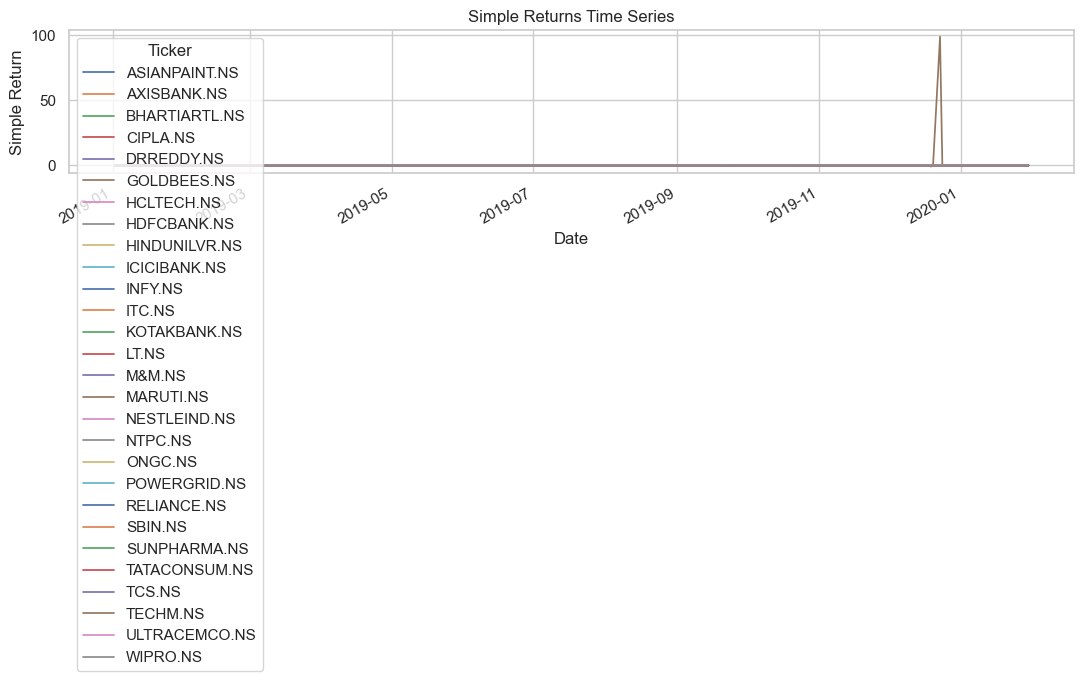

In [5]:
sns.set_theme(style="whitegrid")
ax = simple_returns_df.plot(figsize=(11, 5), linewidth=1.25)
ax.set_title("Simple Returns Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Simple Return")
plt.tight_layout()

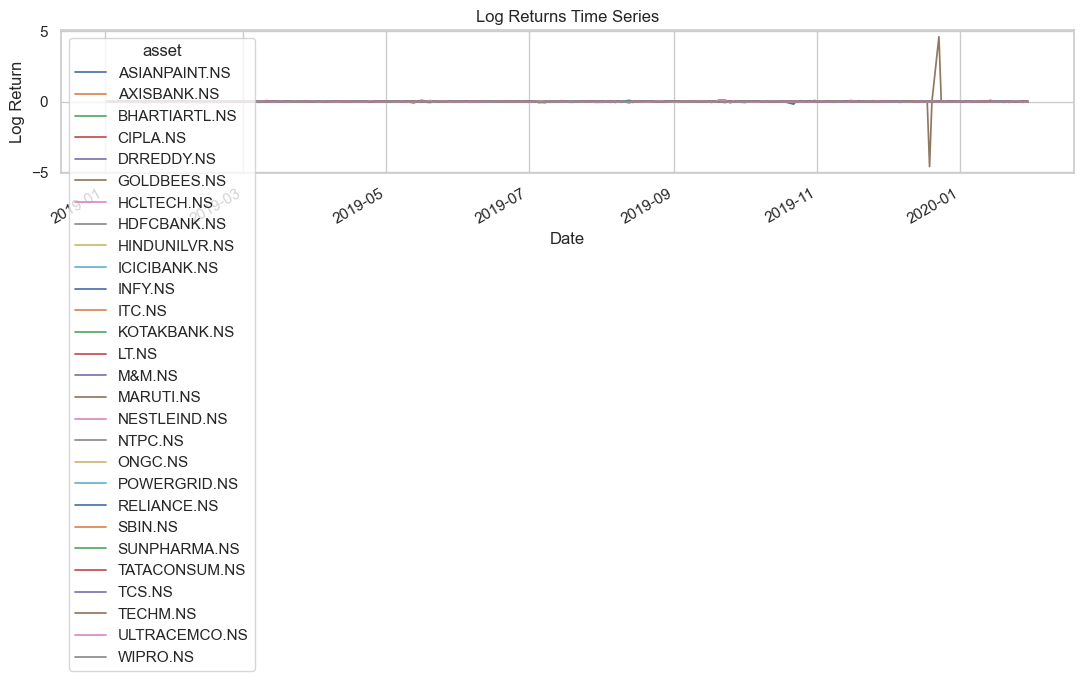

In [6]:
ax = log_returns_df.plot(figsize=(11, 5), linewidth=1.25)
ax.set_title("Log Returns Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
plt.tight_layout()

C:\Users\karth\AppData\Local\Temp\ipykernel_18052\1332006348.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


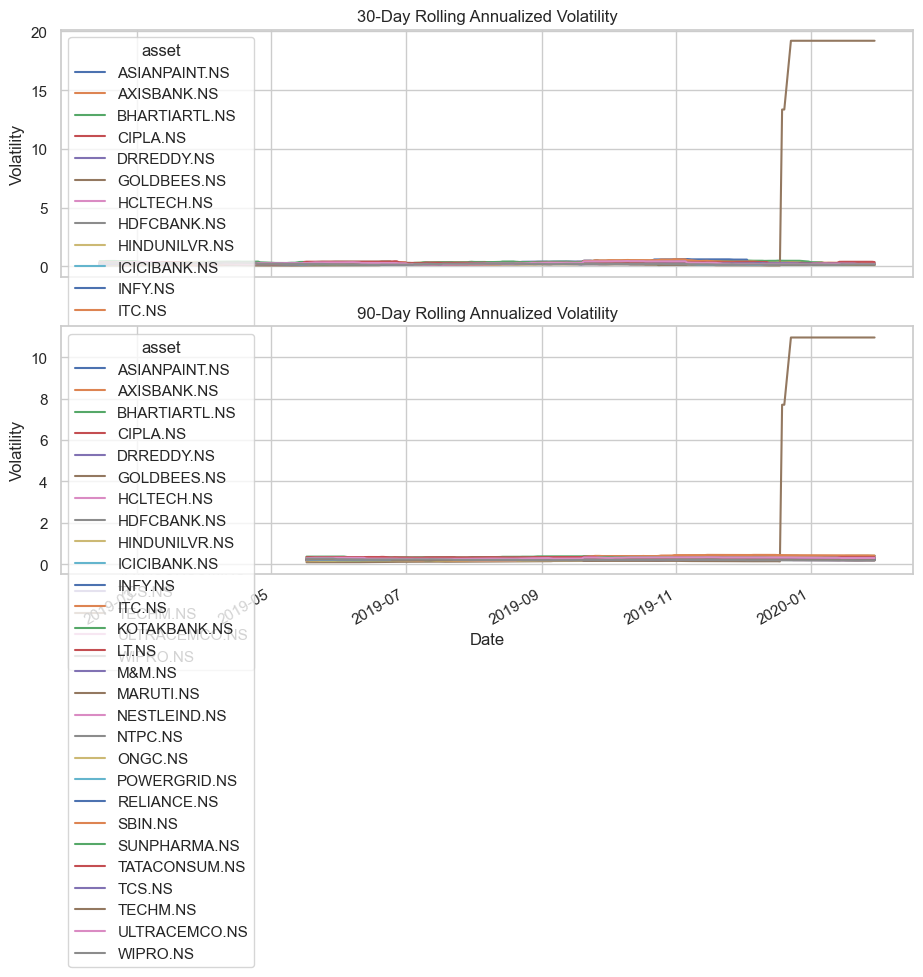

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
rolling_volatility_df.xs("30d", axis=1, level="window").plot(ax=axes[0], linewidth=1.5)
axes[0].set_title("30-Day Rolling Annualized Volatility")
axes[0].set_ylabel("Volatility")

rolling_volatility_df.xs("90d", axis=1, level="window").plot(ax=axes[1], linewidth=1.5)
axes[1].set_title("90-Day Rolling Annualized Volatility")
axes[1].set_ylabel("Volatility")
axes[1].set_xlabel("Date")
plt.tight_layout()

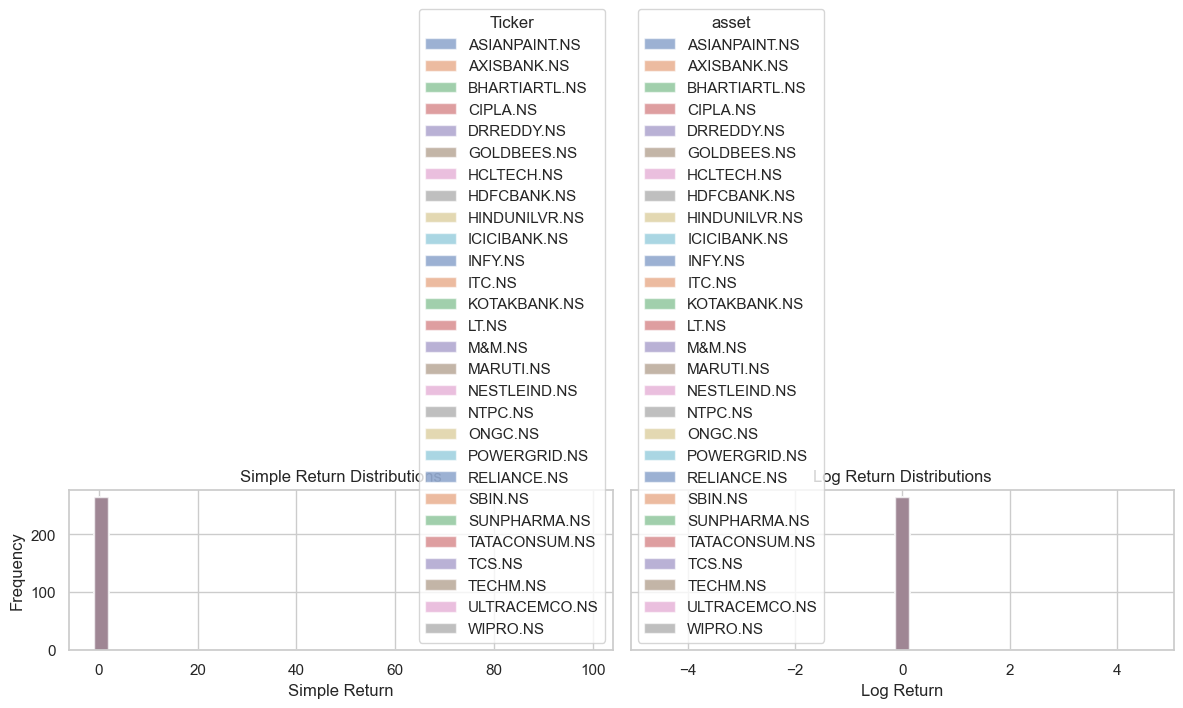

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
simple_returns_df.plot(kind="hist", bins=35, alpha=0.55, ax=axes[0])
axes[0].set_title("Simple Return Distributions")
axes[0].set_xlabel("Simple Return")

log_returns_df.plot(kind="hist", bins=35, alpha=0.55, ax=axes[1])
axes[1].set_title("Log Return Distributions")
axes[1].set_xlabel("Log Return")
plt.tight_layout()

## Interpretation

- `returns_df` is now the stabilized log-return panel used by downstream stages.
- `log_returns_df` preserves the repaired log returns before winsorization.
- The difference between simple and log returns is small for daily data, but log returns compose more cleanly across time.
- Annualized volatility scales daily dispersion by the square root of trading days and gives a comparable risk summary across assets.
- Rolling volatility reveals how risk changes over time, which is essential before building covariance and correlation matrices in the next approved stage.


## Quality Summary


In [ ]:
display(quality_report_df)


## Price Anomaly Report


In [ ]:
display(anomaly_report_df)


## Repair Report


In [ ]:
display(repair_report_df)


## Return Outlier Report


In [ ]:
display(outlier_report_df)


## Stabilization Report


In [ ]:
display(stabilization_report_df)


## Before vs After Cleaning


In [ ]:
pre_clean_log_returns_df = DataPreprocessor.calculate_returns(prices_df, method="log")

def average_pairwise_correlation(frame: pd.DataFrame) -> float:
    correlation_matrix = frame.corr()
    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    correlation_values = upper_triangle.stack()
    return float(correlation_values.mean()) if not correlation_values.empty else float("nan")

before_after_comparison_df = pd.DataFrame(
    {
        "Before Cleaning": [
            pre_clean_log_returns_df.max().max(),
            pre_clean_log_returns_df.min().min(),
            pre_clean_log_returns_df.std().mean() * (252 ** 0.5),
            average_pairwise_correlation(pre_clean_log_returns_df),
        ],
        "After Cleaning": [
            returns_df.max().max(),
            returns_df.min().min(),
            returns_df.std().mean() * (252 ** 0.5),
            average_pairwise_correlation(returns_df),
        ],
    },
    index=["Maximum Return", "Minimum Return", "Annualized Volatility", "Average Correlation"],
).round(4)

display(before_after_comparison_df)


In [9]:
volatility_summary_df

,daily_volatility,annualized_volatility,annualization_factor
asset,,,
ASIANPAINT.NS,0.013893,0.220540,252
AXISBANK.NS,0.016384,0.260092,252
BHARTIARTL.NS,0.021984,0.348990,252
CIPLA.NS,0.014008,0.222368,252
DRREDDY.NS,0.014103,0.223877,252
GOLDBEES.NS,0.401731,6.377278,252
HCLTECH.NS,0.013356,0.212027,252
HDFCBANK.NS,0.012188,0.193477,252
HINDUNILVR.NS,0.011190,0.177638,252


In [10]:
return_comparison_df


,mean_simple_return,mean_log_return,mean_abs_difference,max_abs_difference,return_correlation
asset,,,,,
ASIANPAINT.NS,0.001165,0.001068,0.000097,0.002954,0.999854
AXISBANK.NS,0.000718,0.000584,0.000134,0.002109,0.999894
BHARTIARTL.NS,0.002186,0.001942,0.000244,0.003364,0.999808
CIPLA.NS,-0.000441,-0.000539,0.000098,0.001359,0.999927
DRREDDY.NS,0.000851,0.000751,0.000099,0.001670,0.999895
GOLDBEES.NS,0.372209,0.000921,0.371288,94.394838,0.715115
HCLTECH.NS,0.001025,0.000936,0.000090,0.001973,0.999922
HDFCBANK.NS,0.000608,0.000533,0.000075,0.003782,0.999823
HINDUNILVR.NS,0.000615,0.000552,0.000063,0.003547,0.999840


In [11]:
return_summary_df = pd.DataFrame({
    "Mean Return": simple_returns_df.mean(),
    "Median Return": simple_returns_df.median(),
    "Min Return": simple_returns_df.min(),
    "Max Return": simple_returns_df.max(),
    "Skewness": simple_returns_df.skew(),
    "Kurtosis": simple_returns_df.kurtosis()
})

return_summary_df = return_summary_df.round(4)

display(return_summary_df)

,Mean Return,Median Return,Min Return,Max Return,Skewness,Kurtosis
Ticker,,,,,,
ASIANPAINT.NS,0.0012,0.0007,-0.0364,0.0788,1.2196,5.9209
AXISBANK.NS,0.0007,0.0000,-0.0473,0.0664,0.6803,1.7239
BHARTIARTL.NS,0.0022,0.0011,-0.0629,0.0843,0.6789,1.7241
CIPLA.NS,-0.0004,-0.0008,-0.0369,0.0531,0.4594,1.2683
DRREDDY.NS,0.0009,0.0002,-0.0567,0.0519,-0.1373,2.2679
GOLDBEES.NS,0.3722,0.0005,-0.9900,99.0000,16.2456,263.9456
HCLTECH.NS,0.0010,0.0006,-0.0439,0.0641,0.5212,1.9210
HDFCBANK.NS,0.0006,0.0003,-0.0330,0.0895,1.6450,10.9252
HINDUNILVR.NS,0.0006,0.0008,-0.0248,0.0866,1.7651,12.2100


In [12]:
risk_summary_df = pd.DataFrame({
    "Daily Volatility": simple_returns_df.std(),
    "Annualized Volatility": simple_returns_df.std() * (252 ** 0.5)
})

risk_summary_df["Avg 30D Rolling Vol"] = (
    rolling_volatility_df.xs("30d", axis=1, level="window").mean()
)

risk_summary_df["Avg 90D Rolling Vol"] = (
    rolling_volatility_df.xs("90d", axis=1, level="window").mean()
)

risk_summary_df = risk_summary_df.round(4)

display(risk_summary_df)

,Daily Volatility,Annualized Volatility,Avg 30D Rolling Vol,Avg 90D Rolling Vol
Ticker,,,,
ASIANPAINT.NS,0.0140,0.2225,0.2197,0.2375
AXISBANK.NS,0.0165,0.2616,0.2568,0.2684
BHARTIARTL.NS,0.0222,0.3521,0.3488,0.3510
CIPLA.NS,0.0140,0.2229,0.2222,0.2332
DRREDDY.NS,0.0141,0.2238,0.2235,0.2263
GOLDBEES.NS,6.0935,96.7315,2.5083,1.9513
HCLTECH.NS,0.0134,0.2129,0.2132,0.2204
HDFCBANK.NS,0.0123,0.1954,0.1871,0.2108
HINDUNILVR.NS,0.0113,0.1794,0.1754,0.1926


In [13]:
vol_rank_df = (
    risk_summary_df[["Annualized Volatility"]]
    .sort_values("Annualized Volatility", ascending=False)
)

display(vol_rank_df)

,Annualized Volatility
Ticker,
GOLDBEES.NS,96.7315
BHARTIARTL.NS,0.3521
SBIN.NS,0.3399
TATACONSUM.NS,0.3269
SUNPHARMA.NS,0.3142
MARUTI.NS,0.3007
ONGC.NS,0.2957
ULTRACEMCO.NS,0.2890
M&M.NS,0.2886


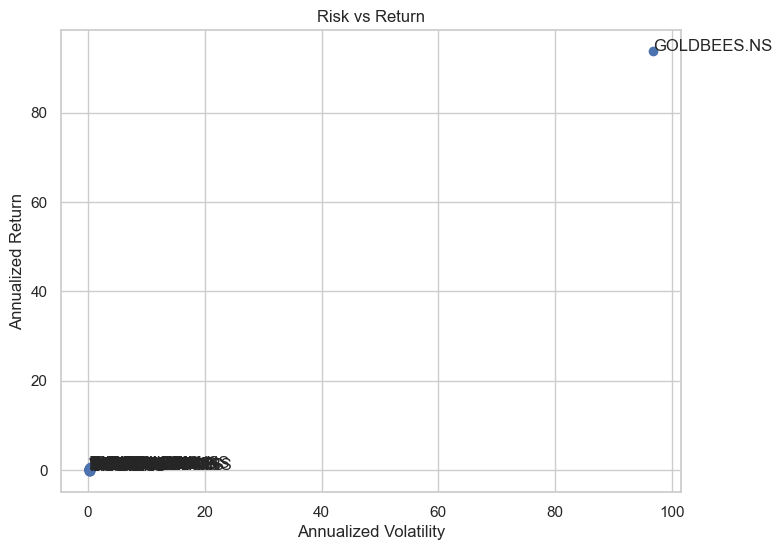

In [14]:
summary_df = pd.DataFrame({
    "Mean Return": simple_returns_df.mean() * 252,
    "Annualized Volatility": simple_returns_df.std() * (252 ** 0.5)
})

plt.figure(figsize=(8,6))
plt.scatter(
    summary_df["Annualized Volatility"],
    summary_df["Mean Return"]
)

for asset in summary_df.index:
    plt.annotate(
        asset,
        (
            summary_df.loc[asset, "Annualized Volatility"],
            summary_df.loc[asset, "Mean Return"]
        )
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Risk vs Return")
plt.grid(True)
plt.show()

In [15]:
risk_return_ratio = (
    summary_df["Mean Return"] /
    summary_df["Annualized Volatility"]
).sort_values(ascending=False)

display(risk_return_ratio)

Ticker
TATACONSUM.NS    1.813148
NESTLEIND.NS     1.692152
BHARTIARTL.NS    1.564627
ICICIBANK.NS     1.453948
ASIANPAINT.NS    1.319199
KOTAKBANK.NS     1.252365
HCLTECH.NS       1.213628
RELIANCE.NS      1.053699
GOLDBEES.NS      0.969659
DRREDDY.NS       0.958090
HINDUNILVR.NS    0.864091
INFY.NS          0.809780
HDFCBANK.NS      0.783984
TCS.NS           0.761850
AXISBANK.NS      0.691750
TECHM.NS         0.609165
ULTRACEMCO.NS    0.522390
SBIN.NS          0.270367
SUNPHARMA.NS     0.236433
POWERGRID.NS     0.168574
WIPRO.NS         0.062121
MARUTI.NS       -0.006803
LT.NS           -0.023239
NTPC.NS         -0.031939
CIPLA.NS        -0.499087
ONGC.NS         -0.504298
ITC.NS          -0.692729
M&M.NS          -0.831972
dtype: float64

In [16]:
gold_returns = returns_df["GOLDBEES.NS"]

gold_returns.sort_values().head()

Date
2019-12-19   -4.606540
2020-01-09   -0.029517
2019-09-06   -0.029088
2019-03-05   -0.020800
2019-06-26   -0.018901
Name: GOLDBEES.NS, dtype: float64

In [17]:
gold_returns.sort_values().tail()

Date
2019-06-20    0.025250
2019-08-26    0.025922
2019-08-02    0.026393
2020-01-03    0.030110
2019-12-23    4.605170
Name: GOLDBEES.NS, dtype: float64

In [19]:
gold_returns[
    abs(gold_returns) > 0.20
]

Date
2019-12-19   -4.60654
2019-12-23    4.60517
Name: GOLDBEES.NS, dtype: float64